In [11]:
!pip install torchvision 

In [13]:
import torch
import torchvision
import torchvision.transforms as transforms

# Convert images to tensors (and normalize to [0,1])
transform = transforms.ToTensor()

trainset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

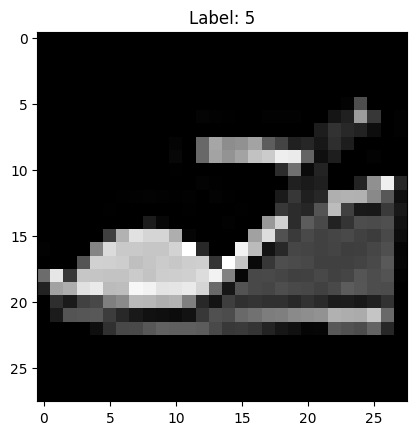

In [14]:
import matplotlib.pyplot as plt

images, labels = next(iter(trainloader))

plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(f"Label: {labels[0].item()}")
plt.show()

## **NOW WE TRAIN OUR MODEL**

In [16]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = Net()

In [17]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    running_loss = 0.0
    
    for images, labels in trainloader:
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {running_loss:.3f}")

Epoch 1, Loss: 517.781
Epoch 2, Loss: 375.268
Epoch 3, Loss: 337.128
Epoch 4, Loss: 313.738
Epoch 5, Loss: 294.288


In [18]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 86.91%
